From https://scikit-learn.org/stable/auto_examples/compose/plot_compare_reduction.html#illustration-of-pipeline-and-gridsearchcv

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.decomposition import NMF, PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC

X, y = load_digits(return_X_y=True)

pipe = Pipeline(
    [
        ("scaling", MinMaxScaler()),
        # the reduce_dim stage is populated by the param_grid
        ("reduce_dim", "passthrough"),
        ("classify", LinearSVC(dual=False, max_iter=10000)),
    ]
)

N_FEATURES_OPTIONS = [2, 4, 8]
C_OPTIONS = [1, 10, 100, 1000]
param_grid = [
    {
        "reduce_dim": [PCA(iterated_power=7), NMF(max_iter=1_000)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "classify__C": C_OPTIONS,
    },
    {
        "reduce_dim": [SelectKBest(mutual_info_classif)],
        "reduce_dim__k": N_FEATURES_OPTIONS,
        "classify__C": C_OPTIONS,
    },
]
reducer_labels = ["PCA", "NMF", "KBest(mutual_info_classif)"]

grid = GridSearchCV(pipe, n_jobs=1, param_grid=param_grid)
grid.fit(X, y)

C:\Users\innov\OneDrive\git\OC-PJ7\venv\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(estimator=Pipeline(steps=[('scaling', MinMaxScaler()),
                                       ('reduce_dim', 'passthrough'),
                                       ('classify',
                                        LinearSVC(dual=False,
                                                  max_iter=10000))]),
             n_jobs=1,
             param_grid=[{'classify__C': [1, 10, 100, 1000],
                          'reduce_dim': [PCA(iterated_power=7),
                                         NMF(max_iter=1000)],
                          'reduce_dim__n_components': [2, 4, 8]},
                         {'classify__C': [1, 10, 100, 1000],
                          'reduce_dim': [SelectKBest(score_func=<function mutual_info_classif at 0x000001559089B370>)],
                          'reduce_dim__k': [2, 4, 8]}])

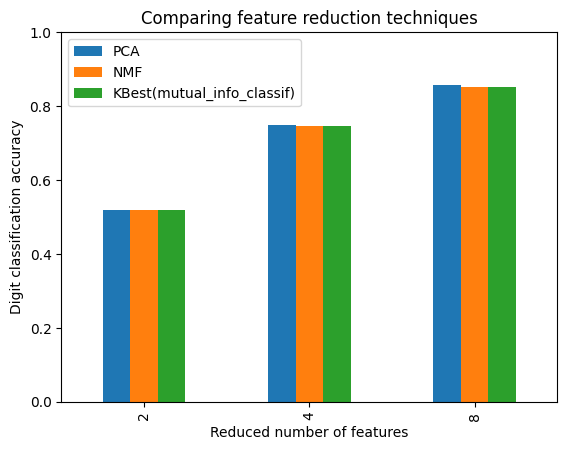

In [2]:
import pandas as pd

mean_scores = np.array(grid.cv_results_["mean_test_score"])
# scores are in the order of param_grid iteration, which is alphabetical
mean_scores = mean_scores.reshape(len(C_OPTIONS), -1, len(N_FEATURES_OPTIONS))
# select score for best C
mean_scores = mean_scores.max(axis=0)
# create a dataframe to ease plotting
mean_scores = pd.DataFrame(
    mean_scores.T, index=N_FEATURES_OPTIONS, columns=reducer_labels
)

ax = mean_scores.plot.bar()
ax.set_title("Comparing feature reduction techniques")
ax.set_xlabel("Reduced number of features")
ax.set_ylabel("Digit classification accuracy")
ax.set_ylim((0, 1))
ax.legend(loc="upper left")

plt.show()

In [3]:
grid.cv_results_

{'mean_fit_time': array([0.00748534, 0.00873737, 0.01333432, 0.04837747, 0.08511653,
        0.13622704, 0.00817714, 0.00896382, 0.01318069, 0.04714308,
        0.08694029, 0.13898058, 0.00697932, 0.00876236, 0.01189046,
        0.04666276, 0.08747435, 0.14453664, 0.00658984, 0.00896459,
        0.01295676, 0.04507804, 0.08761549, 0.15149407, 0.8367609 ,
        0.83795967, 0.94507113, 0.8768549 , 0.87086821, 0.96400762,
        0.84831829, 0.83036866, 0.82698989, 0.86268845, 0.82201524,
        0.83176684]),
 'std_fit_time': array([1.08853283e-03, 4.14567732e-04, 1.74975138e-03, 1.16020331e-02,
        3.74777493e-02, 2.36749959e-02, 2.12930779e-03, 4.41871387e-05,
        1.41296322e-03, 1.06938635e-02, 3.61402324e-02, 2.57310708e-02,
        6.30377868e-04, 4.18863297e-04, 6.20456351e-04, 1.00141852e-02,
        3.70631048e-02, 2.03700328e-02, 4.93465189e-04, 5.36203382e-04,
        1.07710361e-03, 9.69648625e-03, 4.03049867e-02, 2.08024146e-02,
        1.92860877e-02, 4.35756066e-0